# Impact Analysis on AB1104 for Santa Cruz County
We have identified the following components as of importance to understanding how recent policy changes have affected local businesses.

## Economic Impact Analysis
Quantify potential penalties avoided, project delays, and savings retained through AB 1104 reforms.
Estimate the cost to comply with public works registration and reporting requirements.
Estimate total lost investment and increased electricity costs for businesses unable to go solar due to compliance barriers.

## Environmental Cost Analysis
Show benefits in tangible environmental metrics (e.g., carbon emission reductions, local energy resilience).

# Santa Cruz Commercial & Industrial Projects

In order to understand policy impacts we need to take a closer look at how much capacity has been added in Santa Cruz County and the size of a typical commercial/industrial project. We use data from [California DG Stats](https://www.californiadgstats.ca.gov/downloads/) for that. The only IOU operating in the region is PG&E, so we'll focus on the PG&E data.

Below we'll import essential packages and read the data.

In [1]:
import datetime
import glob
import numpy as np
import numpy_financial as npf
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sys

module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import data_analysis as data_analysis
import data_visualization as data_vis

import plotly.io as pio
from plotly.offline import init_notebook_mode

pio.renderers.default = "notebook_connected"
init_notebook_mode(connected=True)

Set data directory containing applications csv files and archive files from DGStats in subdirectories.
DGStats data is released every few weeks/months. The folder 'applications_20251231' contains data from all years 2021-25.

In [2]:
data_dir = '/Users/jenny.folkesson/Data/solar/'
dgstats_dir = os.path.join(data_dir, 'applications_20251231/')
archive_dir = os.path.join(data_dir, 'Interconnection_Applications_Dataset_2024-12-31/')

Load applications from the past 5 years, which for this data set are the complete calendar years 2021-25. We will also merge with archival data in case we need to look further back in history.

In [3]:
import importlib
importlib.reload(data_analysis)
df_total = data_analysis.read_dgstats_data(data_dir=dgstats_dir, archive_dir=archive_dir)

Reading file:  /Users/jenny.folkesson/Data/solar/applications_20251231/applications_sdge_5_year.csv
Reading file:  /Users/jenny.folkesson/Data/solar/applications_20251231/applications_sce_5_year.csv
Reading file:  /Users/jenny.folkesson/Data/solar/applications_20251231/applications_pge_5_year.csv
Reading archive file:  /Users/jenny.folkesson/Data/solar/Interconnection_Applications_Dataset_2024-12-31/SDGE_Interconnection_Applications_Dataset_2024-12-31.csv
Reading archive file:  /Users/jenny.folkesson/Data/solar/Interconnection_Applications_Dataset_2024-12-31/SCE_Interconnection_Applications_Dataset_2024-12-31.csv
Reading archive file:  /Users/jenny.folkesson/Data/solar/Interconnection_Applications_Dataset_2024-12-31/PGE_Interconnection_Applications_Dataset_2024-12-31.csv


## Commercial and Industrial Projects in Santa Cruz County

Select only commercial and industrical applications in Santa Cruz county from the dataframe.

In [4]:
df_scci = df_total.copy()
df_scci = df_scci[df_scci['Service County'].str.lower() == 'santa cruz']
df_scci = df_scci[(df_scci['Customer Sector'] == 'Commercial') | (df_scci['Customer Sector'] == 'Industrial')]

In [5]:
# Inspect data
df_scci

,IOU,Application Status,Utility,Service City,Service County,Technology Type,System Size DC,System Size AC,Storage Capacity (kWh),Storage Size (kW AC),...,Decommissioned Date,Self Installer,Installer Name,Third Party Owned,Third Party Name,Pace Financed,Total System Cost,Cost/Watt,NEM Tariff,Interconnection Program
191,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",352.440,346.627,0.0,0.0,...,NaN,No,Enact Systems Inc,No,NaN,No,867193.0000,2.501804,2.0,NEMMT
984,PGE,Interconnected,PGE,WATSONVILLE,SANTA CRUZ,"Photovoltaic, External Inverter",46.368,45.468,0.0,0.0,...,NaN,No,BLACK & VEATCH CONSTRUCTION INC,No,NaN,No,15000.0000,0.329902,2.0,EXPNEM
1711,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",16.104,15.943,0.0,0.0,...,NaN,No,JUST LEAKS INCORPORATED,No,NaN,No,57338.0000,3.596437,2.0,SNEM
2637,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,"Photovoltaic, External Inverter",47.267,46.536,0.0,0.0,...,NaN,No,SLINGSHOT POWER INC,No,NaN,NaN,0.0001,0.000000,2.0,EXPNEM
5032,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,"Photovoltaic, External Inverter",187.880,184.869,0.0,0.0,...,NaN,No,MYNT SYSTEMS INC,No,NaN,No,440787.0000,2.384320,2.0,EXPNEM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
524752,PGE,Interconnected,PGE,WATSONVILLE,SANTA CRUZ,Photovoltaic,17.520,17.006,0.0,0.0,...,NaN,No,SOLAR SYMPHONY CONSTRUCTION INC,No,NaN,No,51219.0000,3.011819,2.0,SNEM
526722,PGE,Interconnected,PGE,SANTA CRUZ,SANTA CRUZ,Photovoltaic,20.020,19.438,0.0,0.0,...,NaN,No,ALLTERRA SOLAR,No,NaN,No,86700.0000,4.460335,2.0,SNEM
528133,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,Photovoltaic,25.666,25.377,0.0,0.0,...,NaN,No,1ST LIGHT ENERGY INC,No,NaN,No,71422.0000,2.814438,2.0,SNEM
542872,PGE,Interconnected,PGE,SCOTTS VALLEY,SANTA CRUZ,Photovoltaic,11.328,10.982,0.0,0.0,...,NaN,No,ALLTERRA SOLAR,No,NaN,No,65000.0000,5.918776,2.0,SNEM


## DGStats Data Gap

DGStats provides a delayed snapshot of the solar market because it only publishes projects that have been issued Permission to Operate (PTO) by the utility. This delay is particularly significant for commercial and industrial solar projects, which typically have longer interconnection and construction timelines than residential systems.

In April of 2025, we received numbers on application volume directly from PG&E. If we compare the numbers we received directly from PG&E with the corresponding numbers from California DG Stats, this can give us an estimate of how much data we're missing due to the lack of reporting pending applications in the California DG Stats data set.

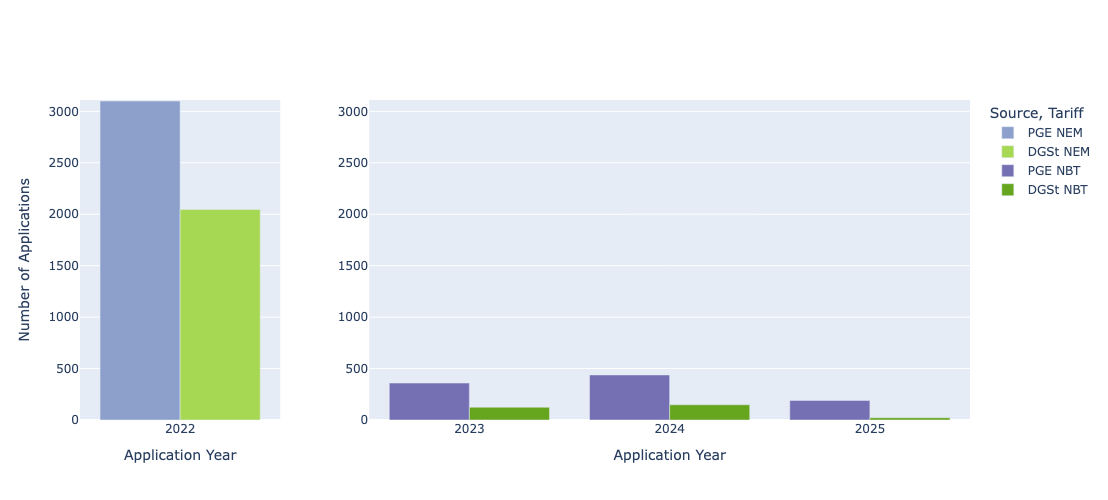

In [11]:
fig = data_vis.dgstats_vs_pge_bargraph(df_total)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "DGStats_vs_PGE.png"), scale=5)
fig.write_html(os.path.join(data_dir, "DGStats_vs_PGE.html"))

## System Sizes in the years 2021-25

Plot histogram of system sizes applied for in the last five years, and compute median size for Santa Cruz County.

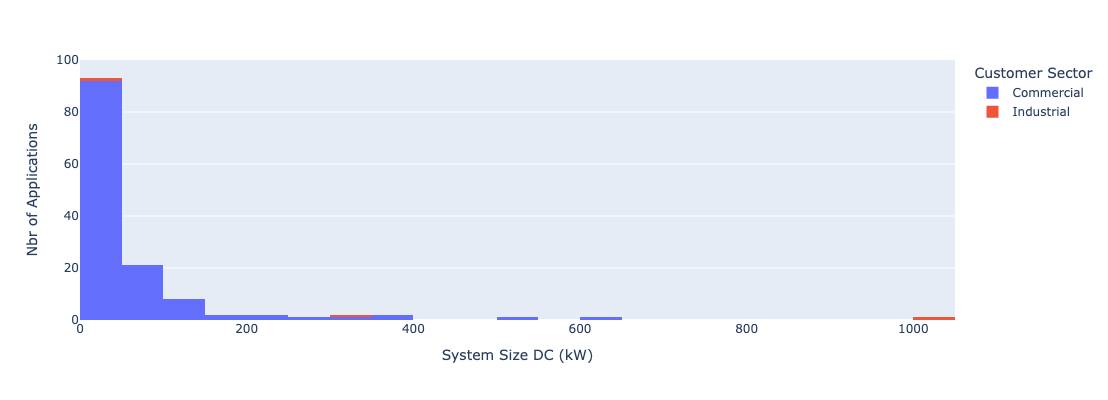

In [8]:
df = df_scci.copy()
df['Year'] = df['App Approved Date'].dt.year
df = df[df['Year'] >= 2021]
fig = px.histogram(df, x='System Size DC', color='Customer Sector')

fig.update_layout(
    autosize=False,
    width=800,
    height=400,
    font=dict(size=12),
    xaxis_title='System Size DC (kW)',
    yaxis_title='Nbr of Applications',
)
fig.update_yaxes(
    range=[0, 100],
)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_system_histogram.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_system_histogram.html"))

In [16]:
# Median application data
df = df_scci.copy()
df = df[df['App Approved Date'].dt.year >= 2021]
# Median capacity
print("Median capacity DC: {} kW".format(df['System Size DC'].median()))

# Median tilt
df['Tilt'] = pd.to_numeric(df['Tilt'], errors='coerce')
print("Median tilt: {} degrees".format(df['Tilt'].median()))

# Median azimuth
df['Azimuth'] = pd.to_numeric(df['Azimuth'], errors='coerce')
print("Median azimuth: {} degrees".format(df['Azimuth'].median()))

Median capacity DC: 29.9085 kW
Median tilt: 18.0 degrees
Median azimuth: 180.0 degrees


## Solar Application Processing Times

Below is a graph showing median commercial and industrial solar application times in Santa Cruz County, divided by color into time from
application received until deemed complete by the utility (Rec-Comp) and from time application is complete until
permission to operate is issued (Comp-Appr).

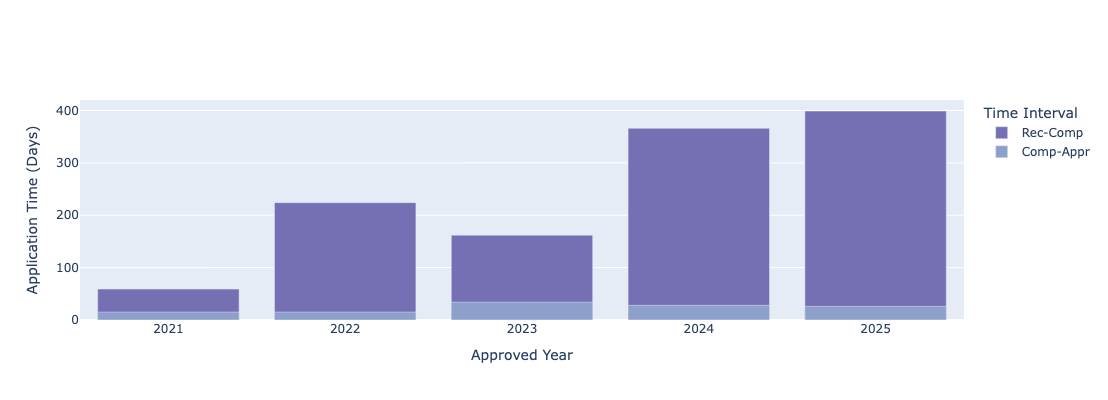

In [20]:
fig = data_vis.application_time_bargraph(df_scci)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_application_time.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_application_time.html"))

## Total Added Capacity in 2021-25

Visualize data applications in terms of applied for capacity per year with NBT and AB 2143 deadlines annotated.

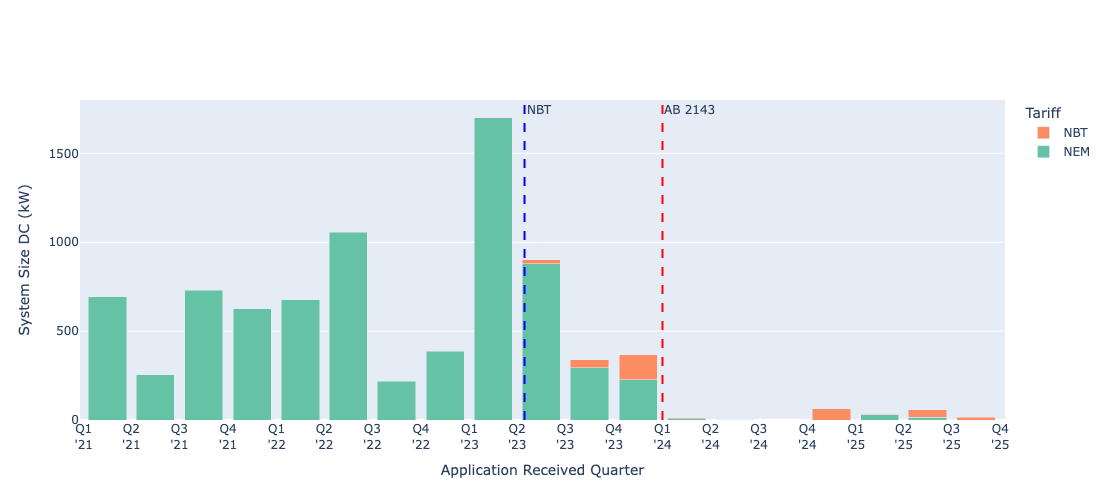

In [39]:
fig = data_vis.commercial_capacity_per_year(df_scci, y_range=1800)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "SC_capacity.png"), scale=5)
fig.write_html(os.path.join(data_dir, "SC_capacity.html"))

Find number of applications in 2024, and compute median annual number of applications for the 10 years prior to the volatility starting with the NBT deadline, so years 2013-22.

In [26]:
df = df_scci.copy()
df = df[['App Received Date', 'System Size DC']]
df = df.set_index('App Received Date').rename_axis(None)
df['Nbr Applications'] = 1
df = df.groupby(df.index.year).sum()
df = df[df.index > 2012]
df

,System Size DC,Nbr Applications
2013,1344.600,28
2014,2927.806,17
2015,301.077,9
2016,2005.947,27
2017,2316.343,23
2018,909.916,18
2019,1300.814,20
2020,1213.766,23
2021,2302.869,34
2022,2338.809,24


In [30]:
# Median application volume in the years 2013-22
df = df[df.index <= 2022]
print(df['Nbr Applications'].mean())

22.3


## Electricity Price

Compare electricity prices from PG&E to the California and US averages. We can get bundled system average rates from [CPUC Historical Electric Cost Data](https://www.cpuc.ca.gov/industries-and-topics/electrical-energy/electric-costs/historical-electric-cost-data) and we can put PG&E rates in perspective by comparing them with the California and US averages using data from the [US Energy Information Administration's Electricity Data Browser](https://www.eia.gov/electricity/data/browser/).
At the time of writing (March 4, 2026), CPUC had not yet updated their Historical Electric Cost Data to include 2025, so we'll look at prices up until 2024.

Inflation data is collected from [FRED](https://fred.stlouisfed.org/series/CPIAUCNS#).

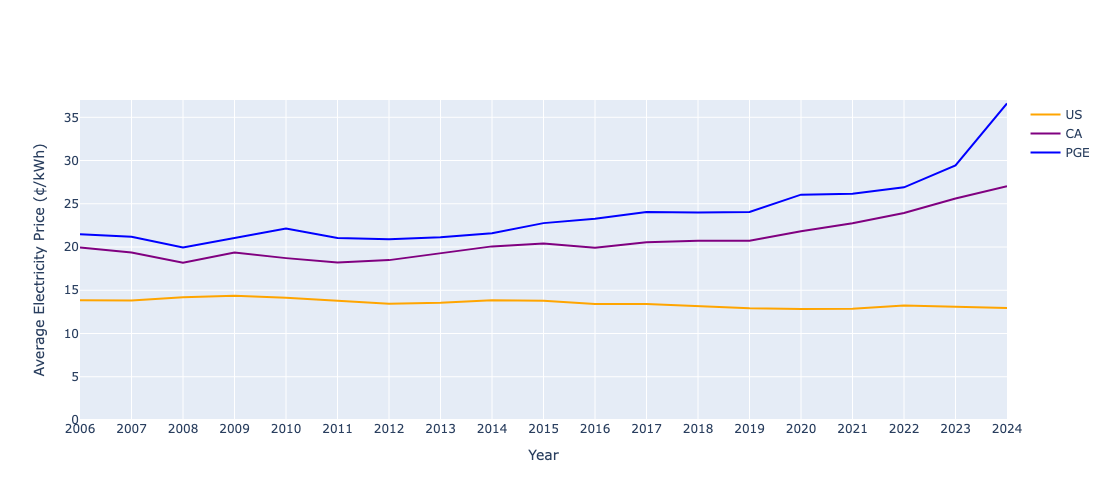

In [40]:
importlib.reload(data_vis)
df = data_analysis.compile_electicity_rates(data_dir)
fig = data_vis.electicity_rates_scatter(df)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "electricity_rates.png"), scale=5)
fig.write_html(os.path.join(data_dir, "electricity_rates.html"))

## Solar Installation Cost Savings

From the the median values of capacity, tilt and azimuth of a commercial solar project, we can estimate what a typical commercial solar system outputs in a year using the [NREL PV Watts Calculator](https://pvwatts.nlr.gov/pvwatts.php).

For Santa Cruz coordinates and the standard loss estimate we get an estimated output of 45 MWh per year, with a range of 43.3 to 45.8 MWh.
We will estimate lower bound, baseline, and upper bound cost and savings estimates for a typical Santa Cruz commercial & industrial system.

### Lower Bound

In [42]:
# Lower bound
df = data_analysis.cost_forecast(25, 43300, 0.4, 2.75, 0.6)
df[['Production (kWh)', 'Cumulative Savings ($)']]

,Production (kWh),Cumulative Savings ($)
1,"43,300","17,320"
2,"43,040","35,010"
3,"42,782","53,076"
4,"42,525","71,529"
5,"42,270","90,375"
6,"42,016","109,623"
7,"41,764","129,282"
8,"41,514","149,360"
9,"41,265","169,867"
10,"41,017","190,811"


In [44]:
# Lower bound cost
cost = 29.9 * 4000
print(cost)

119600.0


In [53]:
# Savings
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
cumsav - cost

444722.0

### Baseline

In [54]:
df = data_analysis.cost_forecast(25, 45000, 0.43, 3.5, 0.5)
df[['Production (kWh)', 'Cumulative Savings ($)']]

,Production (kWh),Cumulative Savings ($)
1,"45,000","19,350"
2,"44,775","39,277"
3,"44,551","59,799"
4,"44,328","80,932"
5,"44,107","102,696"
6,"43,886","125,109"
7,"43,667","148,190"
8,"43,448","171,960"
9,"43,231","196,439"
10,"43,015","221,647"


In [55]:
cost = 29.9 * 3500
print(cost)

104650.0


In [56]:
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
cumsav - cost

599218.0

### Upper Bound

In [58]:
df = data_analysis.cost_forecast(25, 45800, 0.45, 6, 0.4)
df[['Production (kWh)', 'Cumulative Savings ($)']]

,Production (kWh),Cumulative Savings ($)
1,"45,800","20,610"
2,"45,617","42,369"
3,"45,434","65,342"
4,"45,253","89,595"
5,"45,072","115,201"
6,"44,891","142,235"
7,"44,712","170,776"
8,"44,533","200,908"
9,"44,355","232,721"
10,"44,177","266,307"


In [59]:
cost = 29.9 * 3000
print(cost)

89700.0


In [60]:
cumsav = df.iloc[-1]['Cumulative Savings ($)']
cumsav = float(cumsav.replace(",", ""))
cumsav - cost

975791.0

## Environmental Impact

How much of pg&e electricity comes from CO2 sources?
According to PG&E, their base plan emits 16 lbs/MWh of CO2e, which is 16*0.45359237 = 7.26 kg/MWh.
[Power Contents Label Data.](https://www.energy.ca.gov/programs-and-topics/programs/power-source-disclosure-program/power-content-label/annual-power-4)


This is really low compared to the CA utility average, which is 359 lbs CO2e/MWh
which would cause 6.8 metric tonnes of CO2e emissions per year.

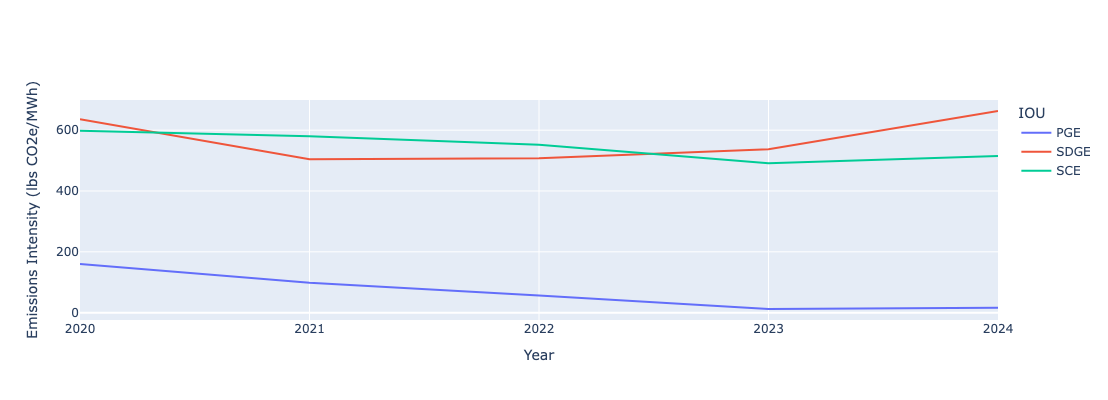

In [61]:
# Data collected from the power contents label data above
# PG&E Greenhouse Gas Emissions Intensity (lbs CO2e/MWh)
data = {'Year': [2024, 2023, 2022, 2021, 2020],
        'PGE': [16, 12, 56, 98, 160],
        'SDGE': [663, 537, 508, 504, 636],
        'SCE': [515, 491, 552, 580, 598]}
df_co2 = pd.DataFrame(data)
df_co2

# fig = px.line(df_co2, x='Year', y=['PGE', 'SDGE', 'SCE'])

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['PGE'],
        name='PGE',
        mode='lines',
    ),
)
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['SDGE'],
        name='SDGE',
        mode='lines',
    ),
)
fig.add_trace(
    go.Scatter(
        x=df_co2['Year'],
        y=df_co2['SCE'],
        name='SCE',
        mode='lines',
    ),
)
fig.update_layout(
    yaxis_title='Emissions Intensity (lbs CO2e/MWh)',
    xaxis_title='Year',
    width=800,
    height=400,
    font=dict(size=12),
    xaxis=dict(tickvals=df_co2['Year']),
    legend={'title': 'IOU'},
)
fig.show()

# Write figure
fig.write_image(os.path.join(data_dir, "emissions.png"), scale=5)
fig.write_html(os.path.join(data_dir, "emissioins.html"))